# Model Performance Comparison

Bu notebook, farklı beyin tümörü sınıflandırma modellerinin performans metriklerini görselleştirir.

In [ ]:
# Gerekli kutuphaneleri import ediyoruz
# pandas: veri islemek icin kullanacagiz
# matplotlib ve seaborn: grafik cizdirmek icin
# numpy: matematiksel islemler icin
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Grafiklerin daha guzel gorunmesi icin stil ayarlari yapiyoruz
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)  # Grafik boyutunu belirliyoruz
plt.rcParams['font.size'] = 11  # Yazi boyutunu ayarliyoruz

# CSV dosyamizi okuyoruz - bu dosyada model sonuclari var
df = pd.read_csv('model_metrics.csv')

# Sutun isimlerini daha anlasilir hale getiriyoruz
# CSV'deki tire isaretlerini kaldiriyoruz
df.columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-score', 'Kappa', 'AUC']

# Veriyi ekrana yazdiralim ve kontrol edelim
print("Model Performans Verileri:")
print("=" * 80)
display(df)

📋 Model Performans Verileri:


,Model,Accuracy,Precision,Recall,Specificity,F1-score,Kappa,AUC
0,DenseNet_SE_LSTM,0.9785,0.9773,0.9810,0.9929,0.9790,0.9711,0.9929
1,DenseNet121_MobileNetV2,0.9258,0.9247,0.9306,0.9751,0.9271,0.9004,0.9906
2,EffNet_ResNet_CrossAttention,0.9764,0.9758,0.9793,0.9922,0.9773,0.9683,0.9985
3,EffNet_SpatialAttention_Residual,0.9731,0.9723,0.9766,0.9911,0.9742,0.9638,0.9979
4,EffNetB0_MobileNetV2_Hybrid,0.9615,0.9606,0.9651,0.9872,0.9629,0.9483,0.9964
5,Hierarchical_CNN_AttnPool,0.9590,0.9582,0.9628,0.9864,0.9602,0.9449,0.9972
6,MultiScale_EffNet,0.9776,0.9777,0.9795,0.9925,0.9785,0.9699,0.9990
7,ResNet18_EffNetB0_Hybrid,0.9329,0.9317,0.9382,0.9776,0.9344,0.9099,0.9917
8,MARK0,0.9486,0.9487,0.9529,0.9827,0.9503,0.9310,0.9905
9,MARK1,0.9573,0.9565,0.9601,0.9857,0.9580,0.9427,0.9961


/tmp/ipykernel_32507/3238567357.py:22: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_32507/3238567357.py:23: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Liberation Sans.
  plt.savefig('/home/ugo/Documents/Python/brain_tumor/model_comparison_all.png', dpi=150, bbox_inches='tight')
/home/ugo/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


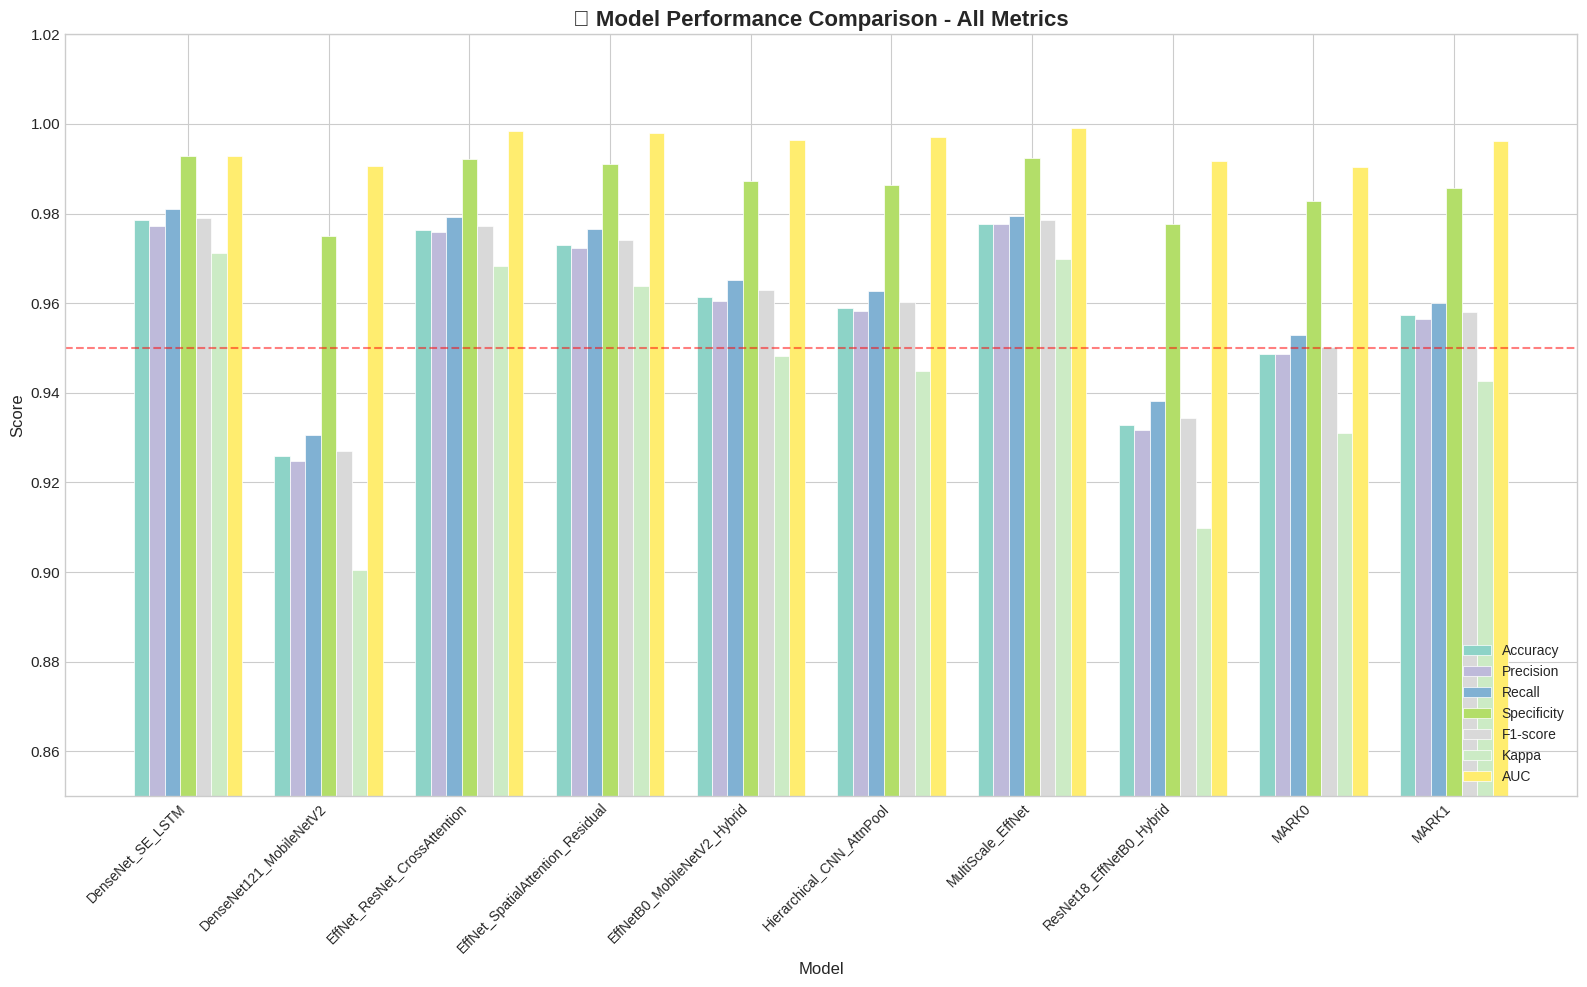

In [ ]:
# 1. Tum metrikleri bir arada gosteren bar grafigi olusturuyoruz
# Bu grafik sayesinde modelleri tum metrikler acisindan karsilastirabiliriz

fig, ax = plt.subplots(figsize=(16, 10))  # Grafik alanini olusturuyoruz

# Kullanacagimiz metrikler - bunlar model basarisini olcen degerler
metrics = ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-score', 'Kappa', 'AUC']

# x ekseni icin pozisyonlari belirliyoruz (her model icin bir pozisyon)
x = np.arange(len(df['Model']))
width = 0.11  # Her bir bar'in genisligi - 7 metrik oldugu icin dar tutuyoruz

# Farkli renkler kullanarak metrikleri ayirt edebilecegiz
colors = plt.cm.Set3(np.linspace(0, 1, len(metrics)))

# Her metrik icin ayri bir bar grubu ciziyoruz
for i, (metric, color) in enumerate(zip(metrics, colors)):
    # x + i * width ile barlari yan yana diziyoruz
    bars = ax.bar(x + i * width, df[metric], width, label=metric, color=color, edgecolor='white', linewidth=0.5)

# Grafik etiketlerini ekliyoruz
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison - All Metrics', fontsize=16, fontweight='bold')

# x eksenindeki model isimlerini ayarliyoruz
ax.set_xticks(x + width * 3)  # Ortaya hizaliyoruz
ax.set_xticklabels(df['Model'], rotation=45, ha='right', fontsize=10)  # 45 derece egik yaziyoruz

ax.legend(loc='lower right', fontsize=10)  # Lejanti sag alta koyuyoruz
ax.set_ylim(0.85, 1.02)  # y eksenini 0.85-1.02 arasinda sinirlandiriyoruz

# %95 esik cizgisi ekliyoruz - bu deger genelde iyi kabul edilen bir sinir
ax.axhline(y=0.95, color='red', linestyle='--', alpha=0.5, label='95% Threshold')

plt.tight_layout()  # Grafik elemanlarinin ustuste binmemesi icin
plt.savefig('/home/ugo/Documents/Python/brain_tumor/model_comparison_all.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_32507/614704181.py:19: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_32507/614704181.py:20: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  plt.savefig('/home/ugo/Documents/Python/brain_tumor/accuracy_ranking.png', dpi=150, bbox_inches='tight')
/home/ugo/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


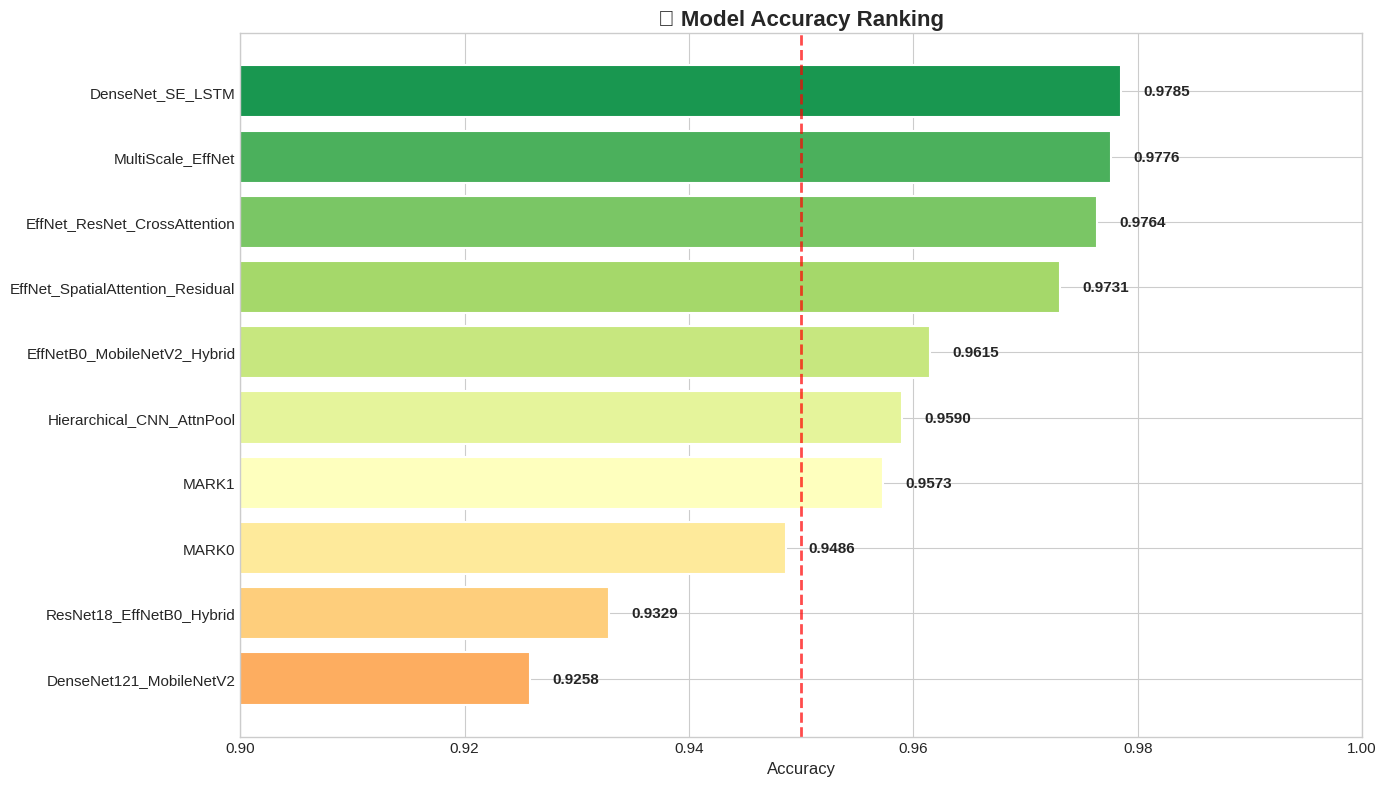

In [ ]:
# 2. Modelleri accuracy degerine gore siraliyoruz
# Yatay bar grafigi kullaniyoruz cunku model isimleri uzun

fig, ax = plt.subplots(figsize=(14, 8))

# Accuracy'e gore kucukten buyuge siraliyoruz
df_sorted = df.sort_values('Accuracy', ascending=True)

# Renk skalasi olusturuyoruz - dusuk degerler kirmizi, yuksek degerler yesil
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(df_sorted)))

# Yatay bar grafigi ciziyoruz
bars = ax.barh(df_sorted['Model'], df_sorted['Accuracy'], color=colors, edgecolor='white', linewidth=1.5)

# Her bar'in yanina degerini yaziyoruz - boylece tam degeri gorebiliriz
for bar, val in zip(bars, df_sorted['Accuracy']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2, 
            f'{val:.4f}', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Accuracy', fontsize=12)
ax.set_title('Model Accuracy Ranking', fontsize=16, fontweight='bold')
ax.set_xlim(0.9, 1.0)  # x eksenini 0.9-1.0 arasinda gosteriyoruz

# %95 esik cizgisi - bu degerin ustundeki modeller basarili sayiliyor
ax.axvline(x=0.95, color='red', linestyle='--', alpha=0.7, linewidth=2)

plt.tight_layout()
plt.savefig('/home/ugo/Documents/Python/brain_tumor/accuracy_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_32507/466077073.py:14: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_32507/466077073.py:15: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Liberation Sans.
  plt.savefig('/home/ugo/Documents/Python/brain_tumor/metrics_heatmap.png', dpi=150, bbox_inches='tight')
/home/ugo/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


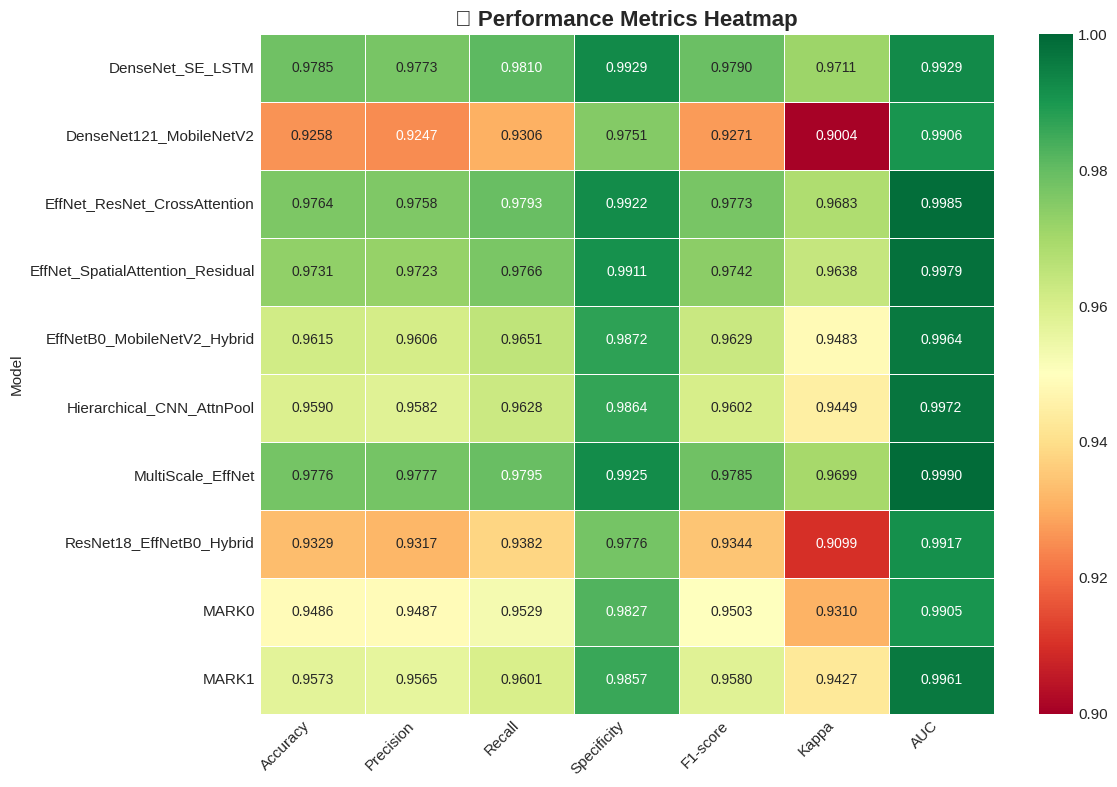

In [ ]:
# 3. Heatmap (Isi haritasi) olusturuyoruz
# Heatmap ile tum degerleri renk tonlariyla gosterebiliriz
# Koyu yesil = iyi, koyu kirmizi = kotu

fig, ax = plt.subplots(figsize=(12, 8))

# Model isimlerini index olarak ayarliyoruz
heatmap_data = df.set_index('Model')[metrics]

# Seaborn kutuphanesi ile heatmap ciziyoruz
# annot=True: hucrelerin icine degerleri yazar
# fmt='.4f': 4 ondalik basamak gosterir
# cmap='RdYlGn': kirmizi-sari-yesil renk skalasi
sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='RdYlGn', 
            linewidths=0.5, ax=ax, vmin=0.9, vmax=1.0,
            annot_kws={'size': 10})

ax.set_title('Performance Metrics Heatmap', fontsize=16, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('/home/ugo/Documents/Python/brain_tumor/metrics_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_32507/1341849676.py:28: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_32507/1341849676.py:29: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Liberation Sans.
  plt.savefig('/home/ugo/Documents/Python/brain_tumor/radar_top5.png', dpi=150, bbox_inches='tight')
/home/ugo/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


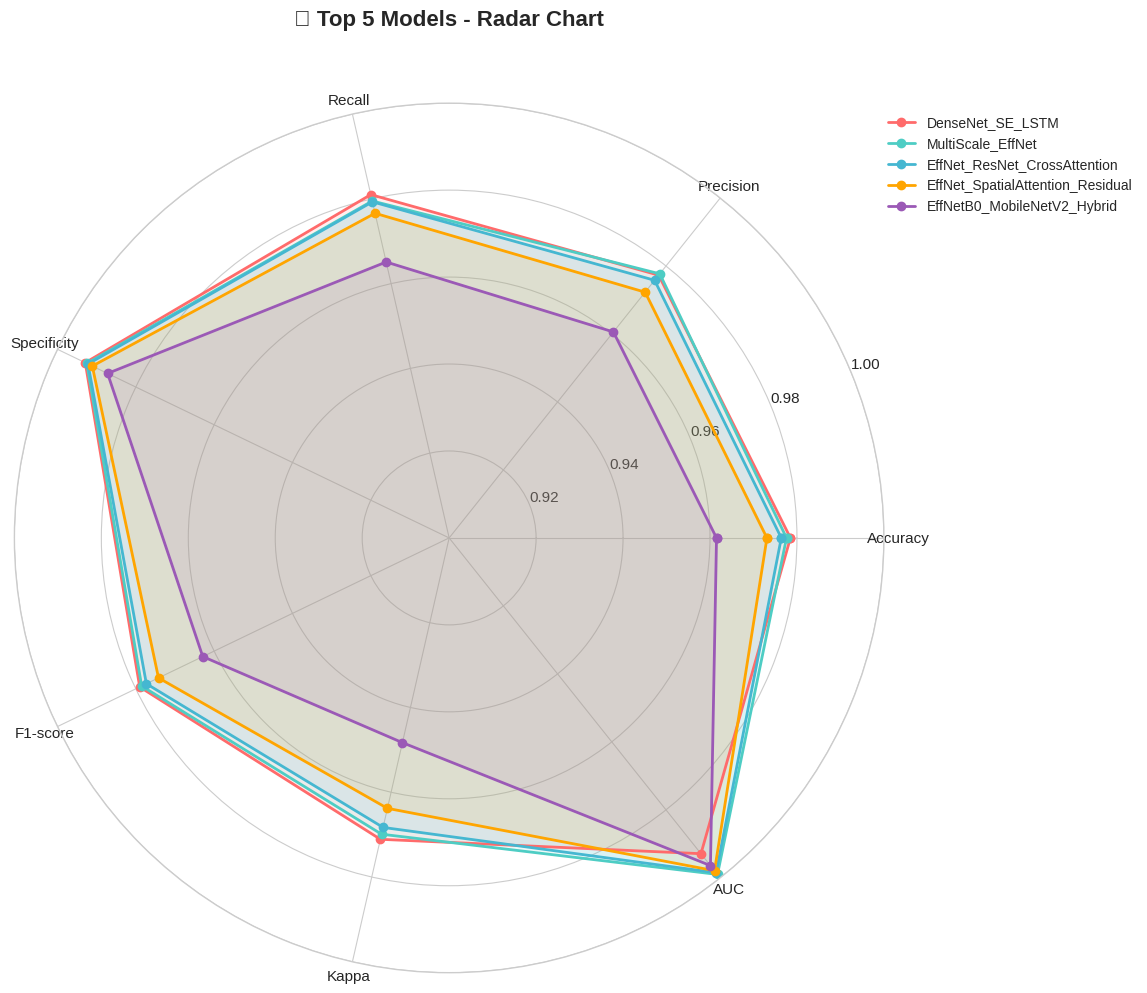

In [ ]:
# 4. Radar (Orumcek) grafigi olusturuyoruz
# En iyi 5 modeli karsilastirmak icin cok kullanisli bir grafik turu
# Her eksen bir metrigi temsil ediyor

from math import pi  # Daire hesaplamalari icin pi sayisini import ediyoruz

# Polar (kutupsal) koordinat sistemi kullaniyoruz
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw=dict(polar=True))

# Accuracy'e gore en iyi 5 modeli seciyoruz
top5 = df.nlargest(5, 'Accuracy')

# Radar grafikte kullanacagimiz kategoriler
categories = ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-score', 'Kappa', 'AUC']
N = len(categories)  # 7 kategori var

# Her kategori icin aci hesapliyoruz (360 dereceyi 7'ye boluyoruz)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # Grafigi kapatmak icin ilk aciyi tekrar ekliyoruz

# Her model icin farkli renk kullaniyoruz
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA500', '#9B59B6']

# Her model icin radar grafigi ciziyoruz
for idx, (_, row) in enumerate(top5.iterrows()):
    values = row[categories].tolist()
    values += values[:1]  # Grafigi kapatmak icin
    
    # Cizgi ve alan ciziyoruz
    ax.plot(angles, values, 'o-', linewidth=2, label=row['Model'], color=colors[idx])
    ax.fill(angles, values, alpha=0.1, color=colors[idx])  # Ici hafif renkli dolduruyoruz

# Eksen etiketlerini ayarliyoruz
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0.9, 1.0)  # Radyal ekseni 0.9-1.0 arasinda gosteriyoruz
ax.set_title('Top 5 Models - Radar Chart', fontsize=16, fontweight='bold', y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize=10)

plt.tight_layout()
plt.savefig('/home/ugo/Documents/Python/brain_tumor/radar_top5.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_32507/172598113.py:17: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_32507/172598113.py:18: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Liberation Sans.
  plt.savefig('/home/ugo/Documents/Python/brain_tumor/f1_vs_auc.png', dpi=150, bbox_inches='tight')
/home/ugo/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


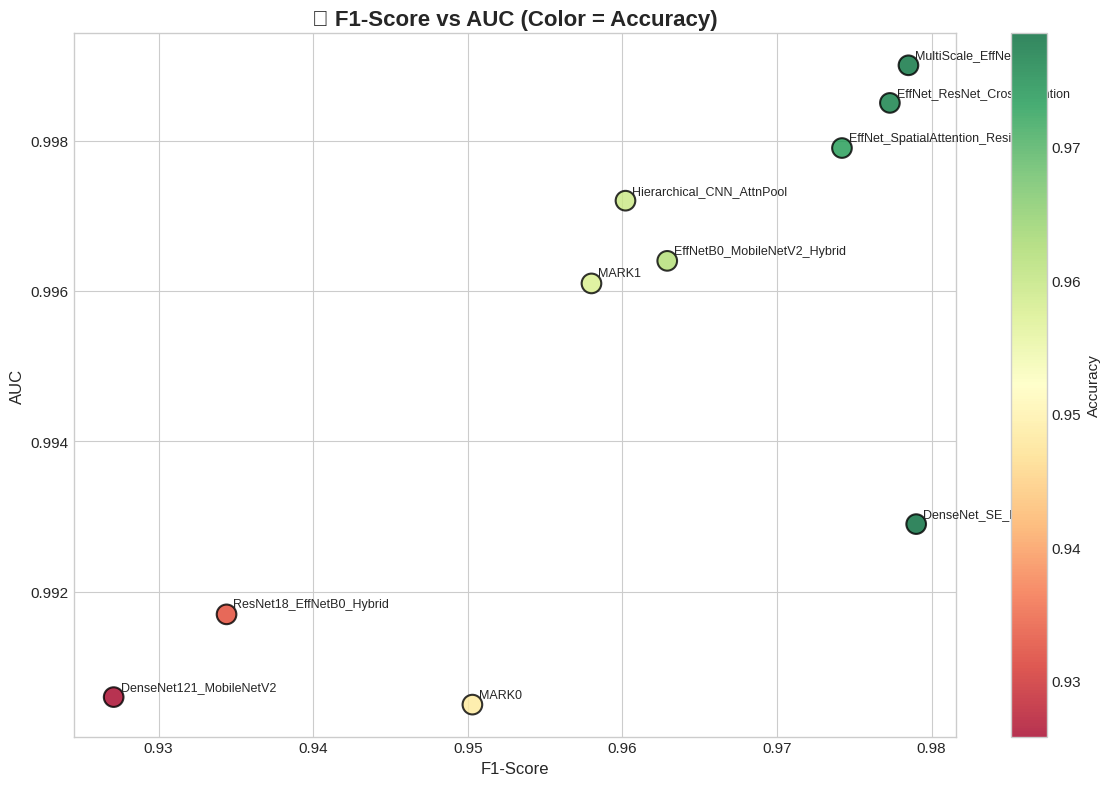

In [ ]:
# 5. F1-Score ve AUC arasindaki iliskiyi gosteren scatter plot
# Her nokta bir modeli temsil ediyor
# Renk accuracy degerini gosteriyor

fig, ax = plt.subplots(figsize=(12, 8))

# Scatter plot ciziyoruz
# s=200: nokta boyutu
# c=df['Accuracy']: renklendirme accuracy'e gore
# cmap='RdYlGn': renk skalasi
scatter = ax.scatter(df['F1-score'], df['AUC'], s=200, c=df['Accuracy'], 
                     cmap='RdYlGn', edgecolors='black', linewidth=1.5, alpha=0.8)

# Her noktanin yanina model ismini yaziyoruz
for idx, row in df.iterrows():
    ax.annotate(row['Model'], (row['F1-score'], row['AUC']), 
                xytext=(5, 5), textcoords='offset points', fontsize=9)

# Renk barini ekliyoruz - hangi rengin hangi accuracy'e karsilik geldigini gosteriyor
plt.colorbar(scatter, label='Accuracy', ax=ax)
ax.set_xlabel('F1-Score', fontsize=12)
ax.set_ylabel('AUC', fontsize=12)
ax.set_title('F1-Score vs AUC (Color = Accuracy)', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('/home/ugo/Documents/Python/brain_tumor/f1_vs_auc.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# 6. Ozet istatistikleri hesaplayip ekrana yazdiriyoruz
# Bu kisimda en iyi modeli ve genel ortalamari goruyoruz

print("PERFORMANS OZETI")
print("=" * 80)

# En yuksek accuracy'e sahip modeli buluyoruz
best_model = df.loc[df['Accuracy'].idxmax()]
print(f"\nEn Iyi Model (Accuracy): {best_model['Model']}")
print(f"   Accuracy: {best_model['Accuracy']:.4f}")
print(f"   F1-Score: {best_model['F1-score']:.4f}")
print(f"   AUC: {best_model['AUC']:.4f}")

# Her metrik icin ortalama ve standart sapmayi hesapliyoruz
print("\nMetrik Ortalamalari:")
for metric in metrics:
    # mean(): ortalama, std(): standart sapma (degerlerin ne kadar dagildigi)
    print(f"   {metric}: {df[metric].mean():.4f} +/- {df[metric].std():.4f}")

# Her metrik icin en iyi modeli buluyoruz
print("\nEn Yuksek Degerler:")
for metric in metrics:
    best_idx = df[metric].idxmax()  # En yuksek degerin indexini buluyoruz
    print(f"   {metric}: {df.loc[best_idx, 'Model']} ({df[metric].max():.4f})")

📊 PERFORMANS ÖZETİ

🏆 En İyi Model (Accuracy): DenseNet_SE_LSTM
   Accuracy: 0.9785
   F1-Score: 0.9790
   AUC: 0.9929

📈 Metrik Ortalamaları:
   Accuracy: 0.9591 ± 0.0186
   Precision: 0.9584 ± 0.0188
   Recall: 0.9626 ± 0.0177
   Specificity: 0.9863 ± 0.0063
   F1-score: 0.9602 ± 0.0184
   Kappa: 0.9450 ± 0.0250
   AUC: 0.9951 ± 0.0033

🎯 En Yüksek Değerler:
   Accuracy: DenseNet_SE_LSTM (0.9785)
   Precision: MultiScale_EffNet (0.9777)
   Recall: DenseNet_SE_LSTM (0.9810)
   Specificity: DenseNet_SE_LSTM (0.9929)
   F1-score: DenseNet_SE_LSTM (0.9790)
   Kappa: DenseNet_SE_LSTM (0.9711)
   AUC: MultiScale_EffNet (0.9990)


/tmp/ipykernel_32507/3435778730.py:26: UserWarning: Glyph 9878 (\N{SCALES}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_32507/3435778730.py:26: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_32507/3435778730.py:27: UserWarning: Glyph 9878 (\N{SCALES}) missing from font(s) Liberation Sans.
  plt.savefig('/home/ugo/Documents/Python/brain_tumor/precision_recall_tradeoff.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_32507/3435778730.py:27: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  plt.savefig('/home/ugo/Documents/Python/brain_tumor/precision_recall_tradeoff.png', dpi=150, bbox_inches='tight')
/home/ugo/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9878 (\N{SCALES}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ugo/.local/lib/python3.10/site-packag

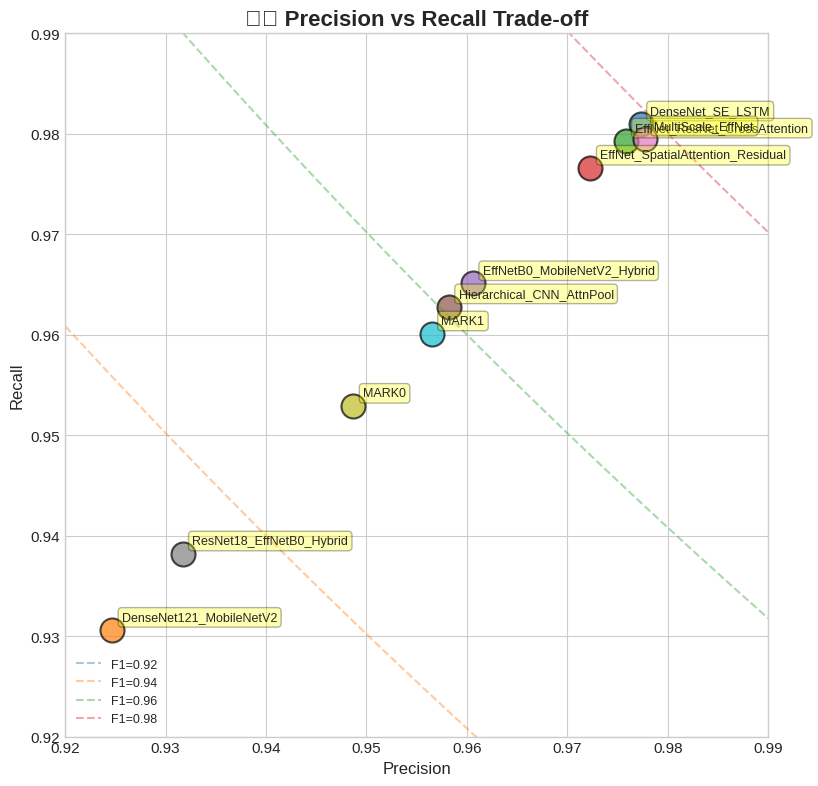

In [ ]:
# 7. Precision ve Recall arasindaki trade-off'u gosteriyoruz
# Genelde precision artarken recall duser veya tam tersi
# Bu grafik bu iliskiyi gosteriyor

fig, ax = plt.subplots(figsize=(12, 8))

# Her model icin bir nokta koyuyoruz
for idx, row in df.iterrows():
    ax.scatter(row['Precision'], row['Recall'], s=300, alpha=0.7, 
               edgecolors='black', linewidth=1.5)
    # Model ismini noktanin yanina yaziyoruz
    ax.annotate(row['Model'], (row['Precision'], row['Recall']), 
                xytext=(7, 7), textcoords='offset points', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))

# F1-score es egrileri ekliyoruz
# Ayni F1 degerini veren precision-recall kombinasyonlarini gosteriyor
for f1 in [0.92, 0.94, 0.96, 0.98]:
    precision_range = np.linspace(0.9, 1.0, 100)
    # F1 = 2 * (precision * recall) / (precision + recall) formulunden recall'i cozuyoruz
    recall_range = (f1 * precision_range) / (2 * precision_range - f1)
    valid = (recall_range >= 0.9) & (recall_range <= 1.0)  # Gecerli aralik
    ax.plot(precision_range[valid], recall_range[valid], '--', alpha=0.4, label=f'F1={f1}')

ax.set_xlabel('Precision', fontsize=12)
ax.set_ylabel('Recall', fontsize=12)
ax.set_title('Precision vs Recall Trade-off', fontsize=16, fontweight='bold')
ax.set_xlim(0.92, 0.99)
ax.set_ylim(0.92, 0.99)
ax.legend(loc='lower left', fontsize=9)
ax.set_aspect('equal')  # x ve y eksenlerini esit olcekte gosteriyoruz

plt.tight_layout()
plt.savefig('/home/ugo/Documents/Python/brain_tumor/precision_recall_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_32507/119591920.py:16: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_32507/119591920.py:17: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Liberation Sans.
  plt.savefig('/home/ugo/Documents/Python/brain_tumor/kappa_vs_auc.png', dpi=150, bbox_inches='tight')
/home/ugo/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


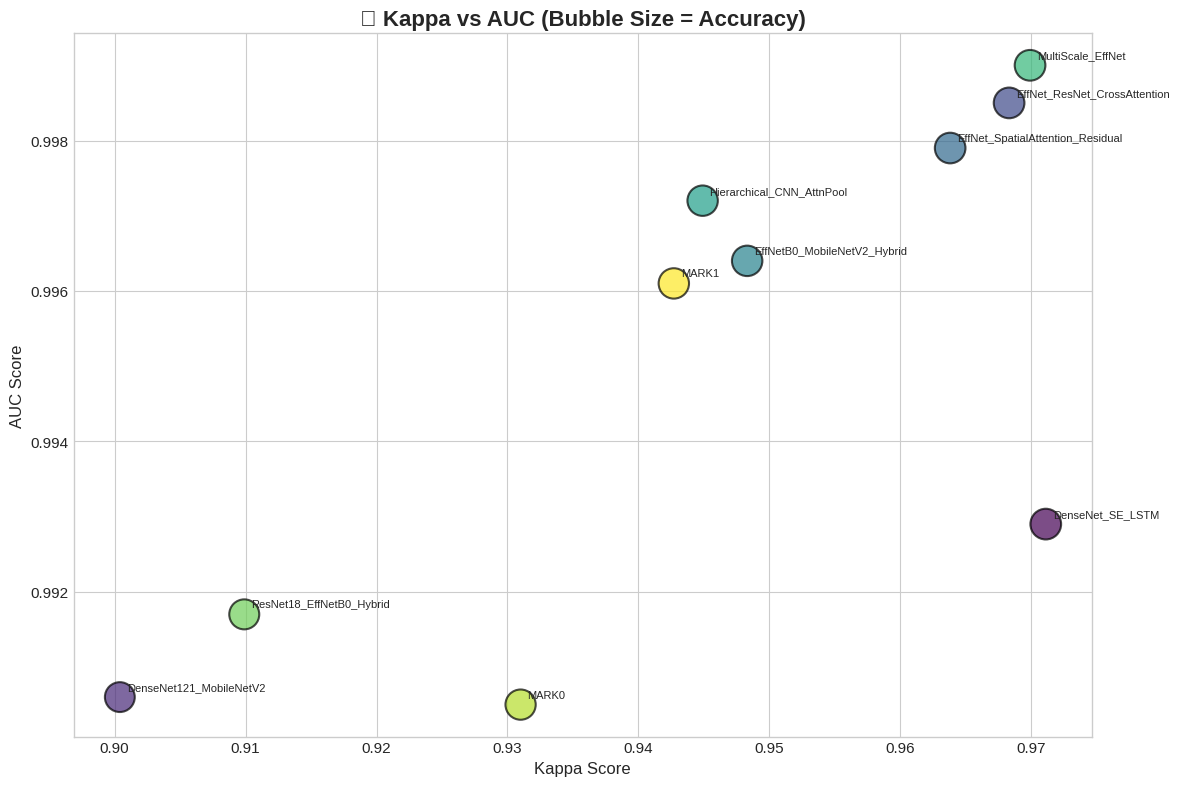

In [ ]:
# 8. Kappa ve AUC karsilastirmasi - bubble chart
# Balon boyutu accuracy'i temsil ediyor
# Kappa: siniflandirma tutarliligi, AUC: genel ayirt edicilik

fig, ax = plt.subplots(figsize=(12, 8))

# Her model icin farkli renk kullaniyoruz
colors = plt.cm.viridis(np.linspace(0, 1, len(df)))

# Bubble chart ciziyoruz - s parametresi balon boyutunu belirliyor
scatter = ax.scatter(df['Kappa'], df['AUC'], s=df['Accuracy']*500, c=colors, 
                     alpha=0.7, edgecolors='black', linewidth=1.5)

# Model isimlerini ekliyoruz
for idx, row in df.iterrows():
    ax.annotate(row['Model'], (row['Kappa'], row['AUC']), 
                xytext=(5, 5), textcoords='offset points', fontsize=8)

ax.set_xlabel('Kappa Score', fontsize=12)
ax.set_ylabel('AUC Score', fontsize=12)
ax.set_title('Kappa vs AUC (Bubble Size = Accuracy)', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('/home/ugo/Documents/Python/brain_tumor/kappa_vs_auc.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_32507/3035004150.py:31: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_32507/3035004150.py:32: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Liberation Sans.
  plt.savefig('/home/ugo/Documents/Python/brain_tumor/metric_distributions.png', dpi=150, bbox_inches='tight')
/home/ugo/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


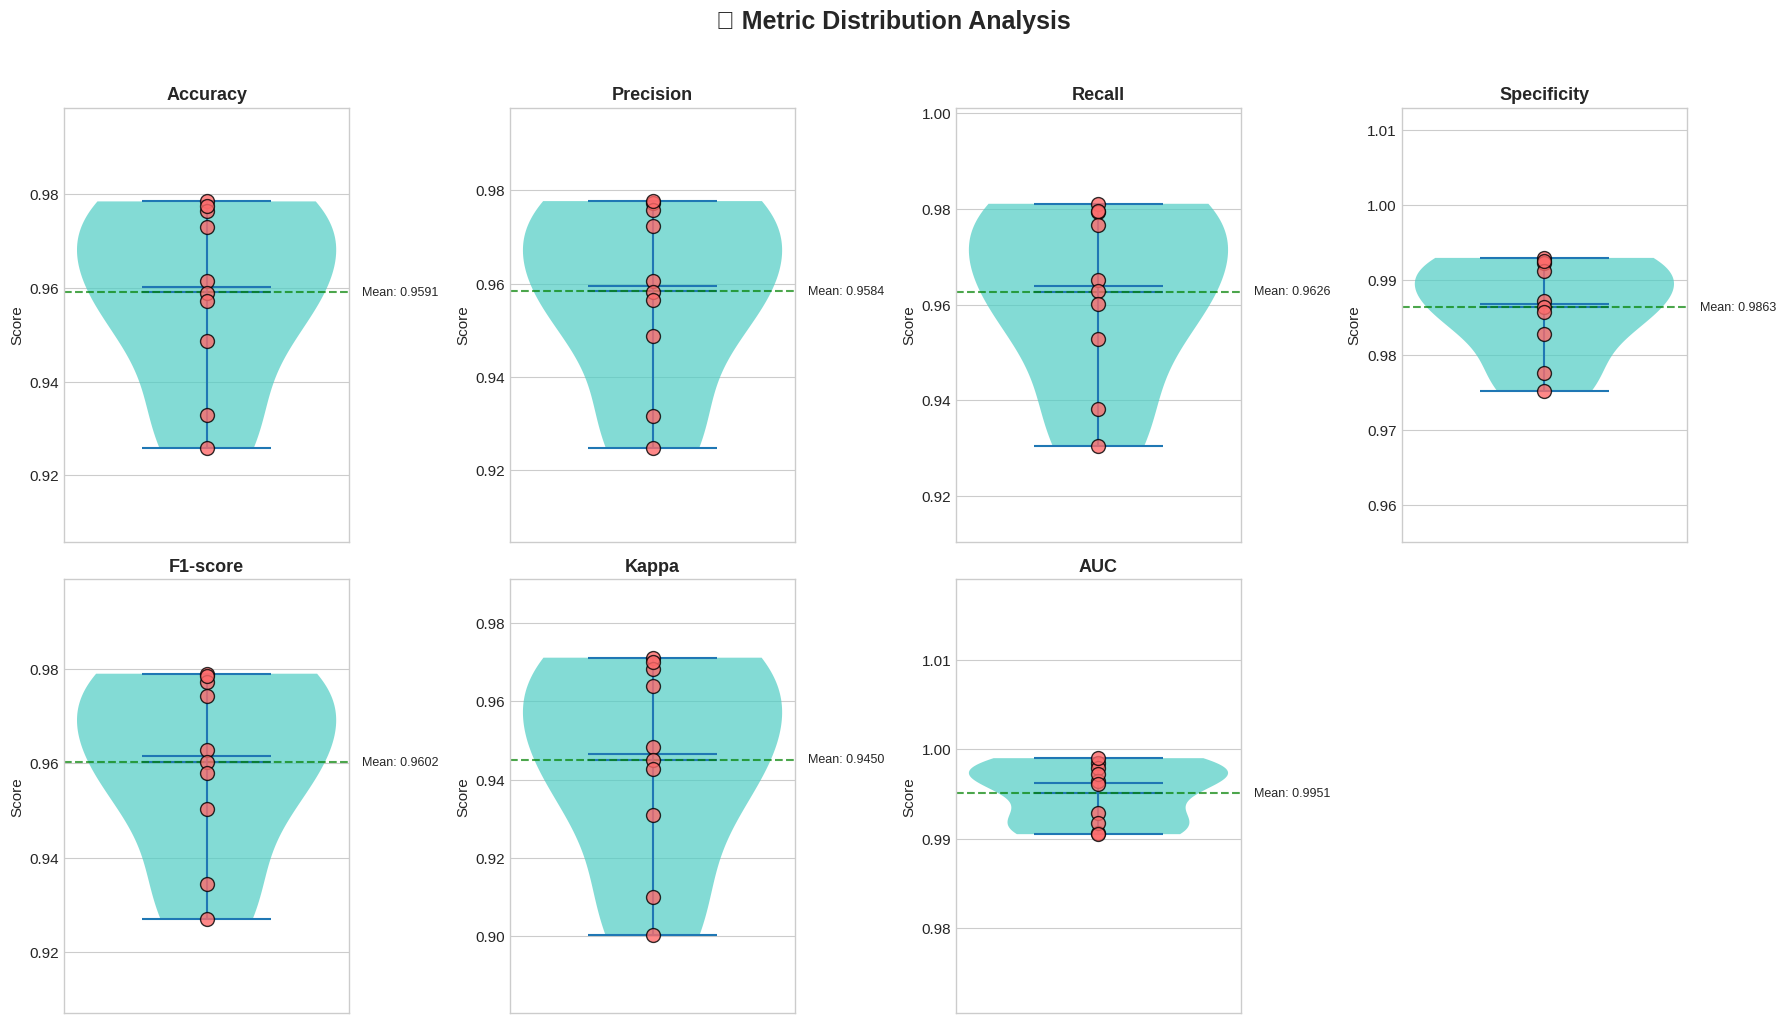

In [ ]:
# 9. Her metrik icin violin plot olusturuyoruz
# Violin plot degerlerin dagilimini gosteriyor
# Kalin kisimlar: degerlerin yogunlastigi bolge

fig, axes = plt.subplots(2, 4, figsize=(18, 10))  # 2 satir, 4 sutun
axes = axes.flatten()  # 2D diziyi 1D'ye ceviriyoruz

for i, metric in enumerate(metrics):
    ax = axes[i]
    values = df[metric].values  # Bu metrik icin tum degerleri aliyoruz
    
    # Violin plot ciziyoruz
    parts = ax.violinplot([values], positions=[0], showmeans=True, showmedians=True)
    parts['bodies'][0].set_facecolor('#4ECDC4')  # Rengi ayarliyoruz
    parts['bodies'][0].set_alpha(0.7)
    
    # Her bir model icin nokta ekliyoruz
    ax.scatter(np.zeros(len(values)), values, s=100, c='#FF6B6B', 
               edgecolors='black', zorder=3, alpha=0.8)
    
    ax.set_title(f'{metric}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Score')
    ax.set_xticks([])  # x ekseninde etiket yok
    ax.set_ylim(min(values) - 0.02, max(values) + 0.02)
    
    # Ortalama cizgisi ekliyoruz
    ax.axhline(y=values.mean(), color='green', linestyle='--', alpha=0.7)
    ax.text(0.3, values.mean(), f'Mean: {values.mean():.4f}', fontsize=9, va='center')

# 8. grafik alani bos kaliyor (7 metrik var), onu gizliyoruz
axes[-1].axis('off')

plt.suptitle('Metric Distribution Analysis', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/home/ugo/Documents/Python/brain_tumor/metric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_32507/946442035.py:26: UserWarning: Glyph 127941 (\N{SPORTS MEDAL}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_32507/946442035.py:27: UserWarning: Glyph 127941 (\N{SPORTS MEDAL}) missing from font(s) Liberation Sans.
  plt.savefig('/home/ugo/Documents/Python/brain_tumor/model_rankings.png', dpi=150, bbox_inches='tight')
/home/ugo/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127941 (\N{SPORTS MEDAL}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


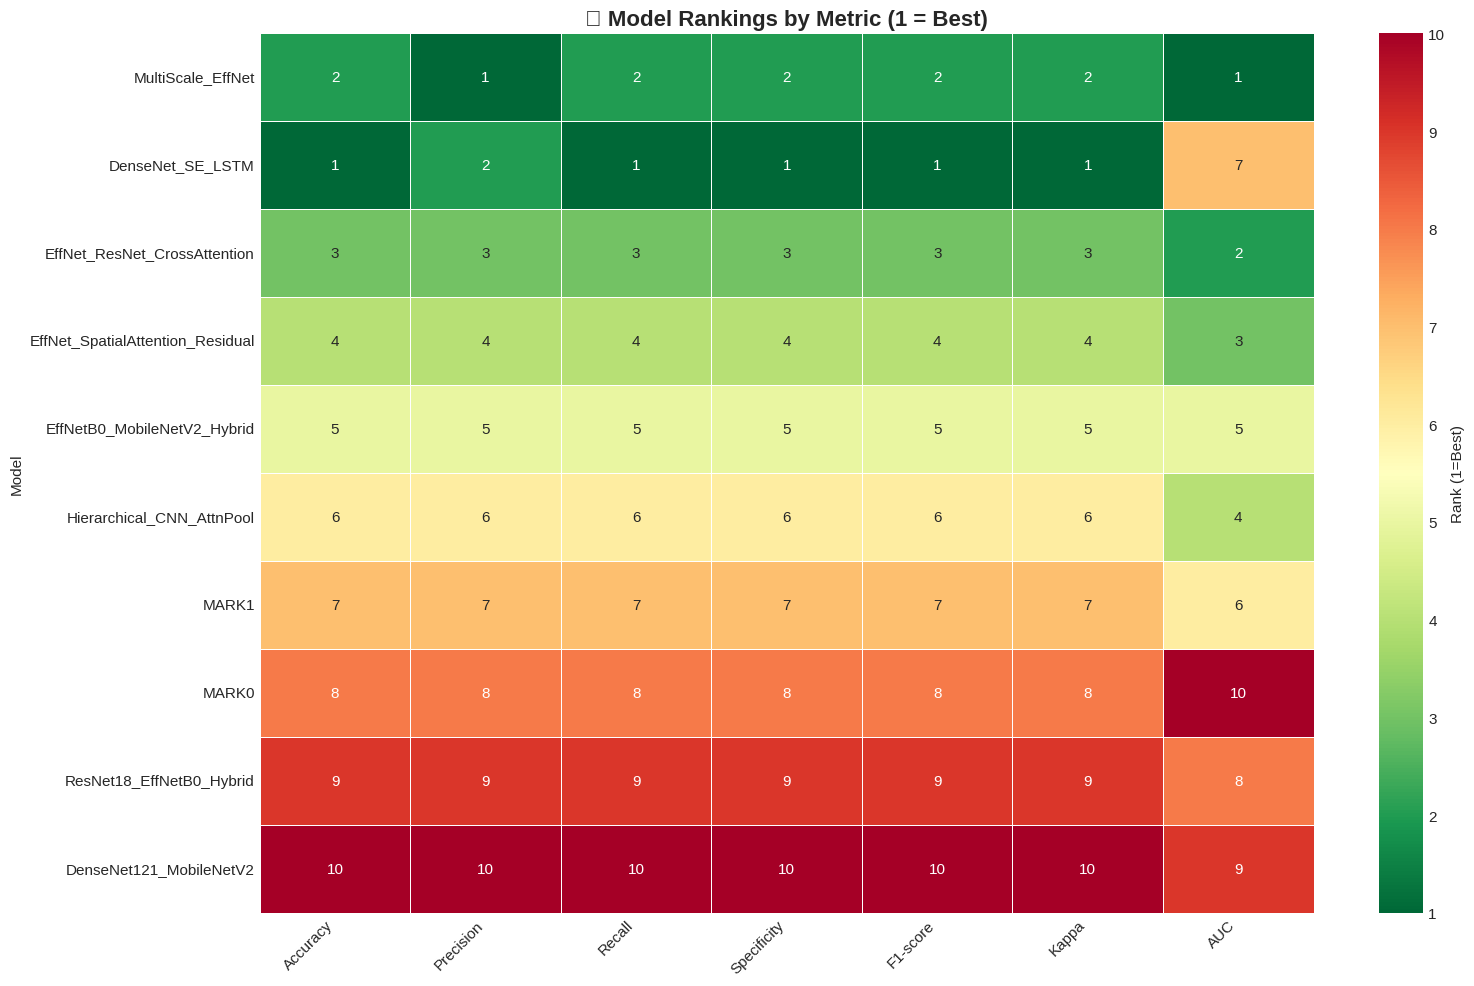


🏆 Ortalama Sıralama:
   MultiScale_EffNet: 1.71
   DenseNet_SE_LSTM: 2.00
   EffNet_ResNet_CrossAttention: 2.86
   EffNet_SpatialAttention_Residual: 3.86
   EffNetB0_MobileNetV2_Hybrid: 5.00
   Hierarchical_CNN_AttnPool: 5.71
   MARK1: 6.86
   MARK0: 8.29
   ResNet18_EffNetB0_Hybrid: 8.86
   DenseNet121_MobileNetV2: 9.86


In [ ]:
# 10. Her metrik icin model siralamasi olusturuyoruz
# Bu tablo hangi modelin hangi metrikte kacinci oldugunu gosteriyor

fig, ax = plt.subplots(figsize=(16, 10))

# Siralama icin yeni bir dataframe olusturuyoruz
rankings = pd.DataFrame()
rankings['Model'] = df['Model']

# Her metrik icin siralama hesapliyoruz (1 = en iyi)
for metric in metrics:
    rankings[metric + '_rank'] = df[metric].rank(ascending=False).astype(int)

# Ortalama siralamayi hesapliyoruz
rank_cols = [col for col in rankings.columns if '_rank' in col]
rankings['Avg_Rank'] = rankings[rank_cols].mean(axis=1)
rankings = rankings.sort_values('Avg_Rank')  # Ortalama siralamaya gore siraliyoruz

# Heatmap icin veriyi hazirliyoruz
rank_data = rankings.set_index('Model')[rank_cols]
rank_data.columns = metrics  # Sutun isimlarini duzenliyoruz

# Heatmap ciziyoruz - dusuk siralama (1) yesil, yuksek siralama kirmizi
sns.heatmap(rank_data, annot=True, fmt='d', cmap='RdYlGn_r', 
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Rank (1=Best)'})

ax.set_title('Model Rankings by Metric (1 = Best)', fontsize=16, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('/home/ugo/Documents/Python/brain_tumor/model_rankings.png', dpi=150, bbox_inches='tight')
plt.show()

# Ortalama siralamalari yazdiriyoruz
print("\nOrtalama Siralama:")
for _, row in rankings.iterrows():
    print(f"   {row['Model']}: {row['Avg_Rank']:.2f}")

/tmp/ipykernel_32507/4210462240.py:19: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_32507/4210462240.py:20: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  plt.savefig('/home/ugo/Documents/Python/brain_tumor/parallel_coordinates.png', dpi=150, bbox_inches='tight')
/home/ugo/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


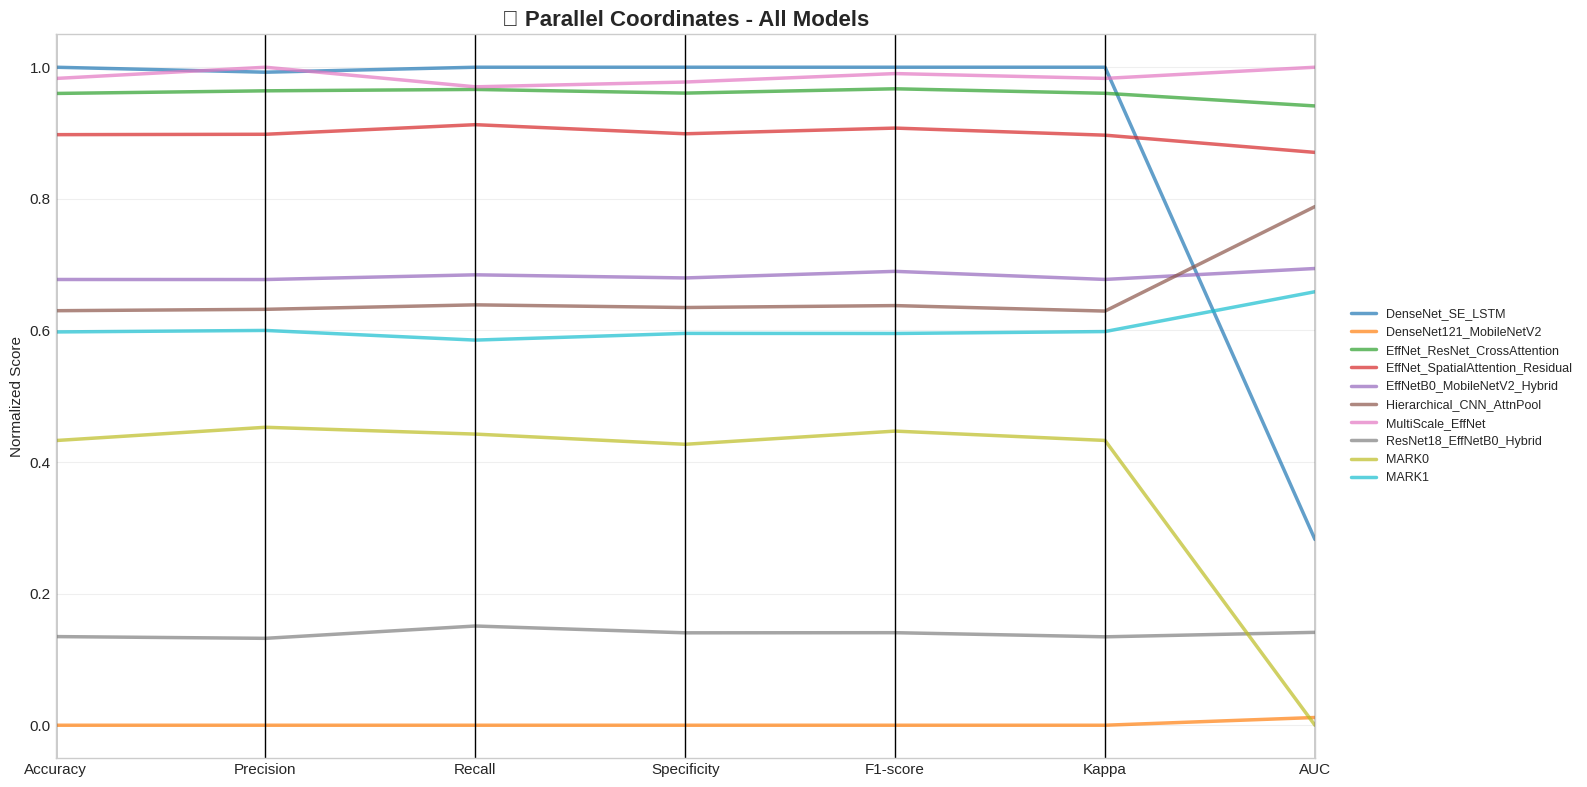

In [ ]:
# 11. Parallel Coordinates (Paralel Koordinatlar) grafigi
# Her dikey cizgi bir metrigi temsil ediyor
# Her renkli cizgi bir modeli temsil ediyor

from pandas.plotting import parallel_coordinates

fig, ax = plt.subplots(figsize=(16, 8))

# Degerleri 0-1 arasina normalize ediyoruz
# Boylece farkli olceklerdeki metrikleri karsilastirabiliriz
df_normalized = df.copy()
for col in metrics:
    min_val = df[col].min()
    max_val = df[col].max()
    df_normalized[col] = (df[col] - min_val) / (max_val - min_val)

# Parallel coordinates grafigi ciziyoruz
parallel_coordinates(df_normalized[['Model'] + metrics], 'Model', ax=ax, 
                     colormap='tab10', linewidth=2.5, alpha=0.7)

ax.set_title('Parallel Coordinates - All Models', fontsize=16, fontweight='bold')
ax.set_ylabel('Normalized Score')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/ugo/Documents/Python/brain_tumor/parallel_coordinates.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_32507/3965500911.py:24: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_32507/3965500911.py:25: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Liberation Sans.
  plt.savefig('/home/ugo/Documents/Python/brain_tumor/performance_gap.png', dpi=150, bbox_inches='tight')
/home/ugo/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


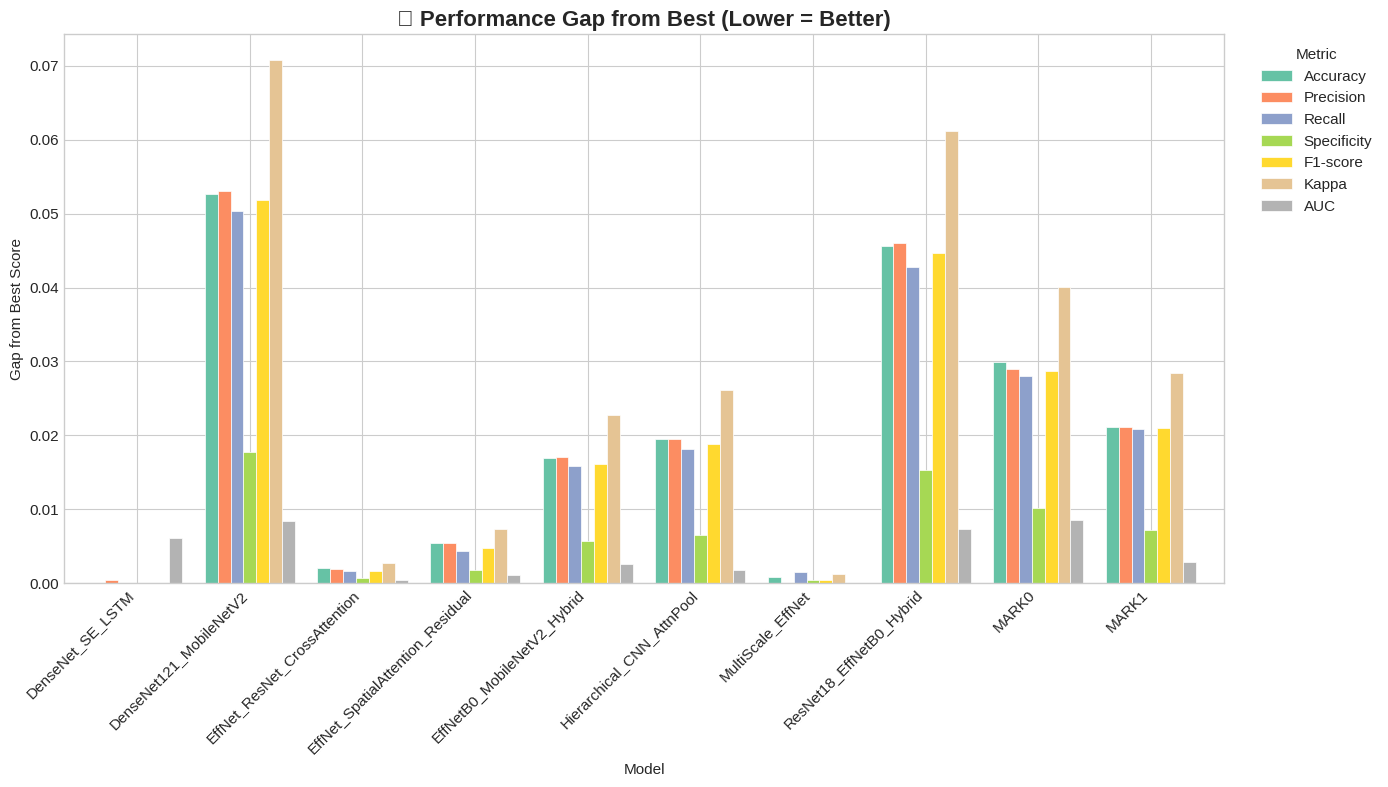

In [ ]:
# 12. Performance Gap (Performans Farki) analizi
# Her modelin en iyi degerden ne kadar geride oldugunu gosteriyoruz
# Dusuk fark = daha iyi

fig, ax = plt.subplots(figsize=(14, 8))

# Her metrik icin en iyi degeri buluyoruz
best_values = df[metrics].max()

# Fark hesaplayacagimiz dataframe
gap_data = pd.DataFrame()
gap_data['Model'] = df['Model']

# Her metrik icin en iyiden farki hesapliyoruz
for metric in metrics:
    gap_data[metric] = best_values[metric] - df[metric]

# Bar grafigi icin pivot tablo olusturuyoruz
pivot_gap = gap_data.set_index('Model')[metrics]
pivot_gap.plot(kind='bar', ax=ax, width=0.8, colormap='Set2', edgecolor='white', linewidth=0.5)

ax.set_title('Performance Gap from Best (Lower = Better)', fontsize=16, fontweight='bold')
ax.set_xlabel('Model')
ax.set_ylabel('Gap from Best Score')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig('/home/ugo/Documents/Python/brain_tumor/performance_gap.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_32507/844174640.py:13: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_32507/844174640.py:14: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) Liberation Sans.
  plt.savefig('/home/ugo/Documents/Python/brain_tumor/metric_correlation.png', dpi=150, bbox_inches='tight')
/home/ugo/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


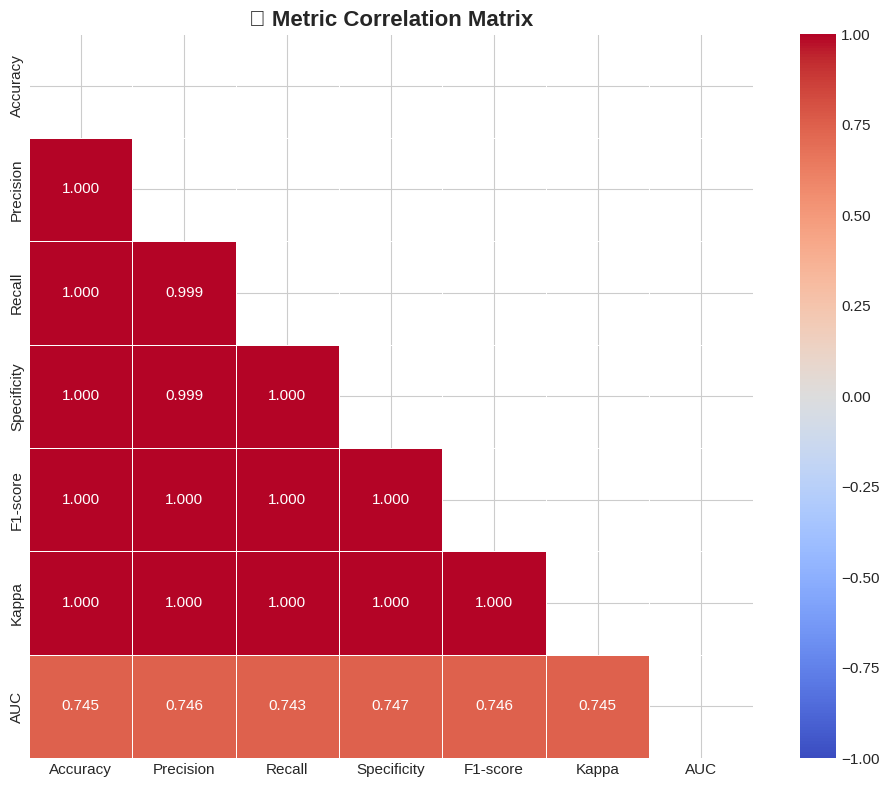

In [ ]:
# 13. Metrikler arasindaki korelasyon matrisi
# Hangi metrikler birbirleriyle iliskili?
# 1'e yakin: guclu pozitif iliski, -1'e yakin: guclu negatif iliski

fig, ax = plt.subplots(figsize=(10, 8))

# Korelasyon matrisini hesapliyoruz
corr_matrix = df[metrics].corr()

# Sadece alt ucgeni gosteriyoruz (ust ucgen tekrar olur)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Heatmap olarak ciziyoruz
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='coolwarm',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1, center=0,
            square=True, annot_kws={'size': 11})

ax.set_title('Metric Correlation Matrix', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('/home/ugo/Documents/Python/brain_tumor/metric_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_32507/3644565806.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(metrics, rotation=45, ha='right')
/home/ugo/.local/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 129351 (\N{FIRST PLACE MEDAL}) missing from font(s) Liberation Sans.
  fig.canvas.draw()
/home/ugo/.local/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 129352 (\N{SECOND PLACE MEDAL}) missing from font(s) Liberation Sans.
  fig.canvas.draw()
/home/ugo/.local/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 129353 (\N{THIRD PLACE MEDAL}) missing from font(s) Liberation Sans.
  fig.canvas.draw()
/home/ugo/.local/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Liberation Sans.
  fig.canvas.draw()
/tmp/ipykernel_32507/3644565806.py:39: UserWarning: Glyph 129351 (\N{FIRST PLACE MED

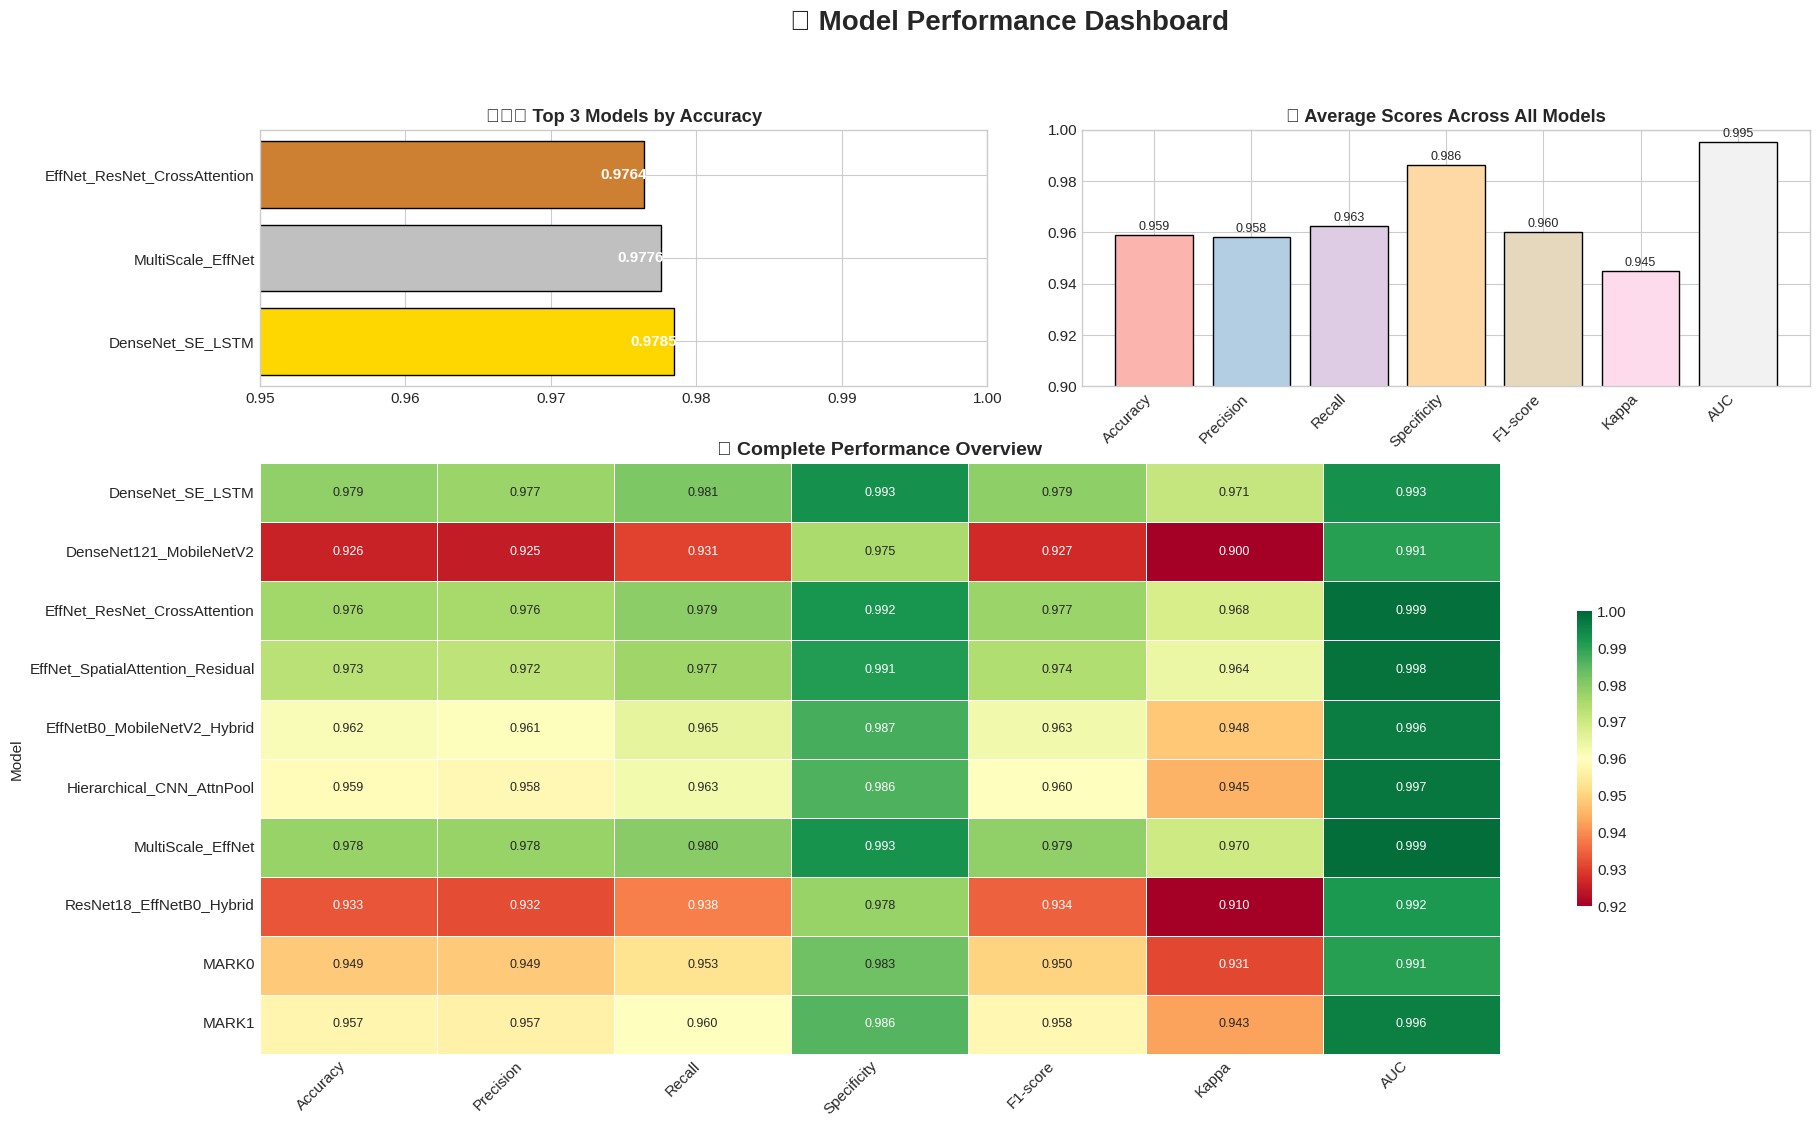


✅ Tüm grafikler başarıyla oluşturuldu ve kaydedildi!


In [ ]:
# 14. Final Dashboard - Tum onemli bilgileri tek bir gorunumde topluyoruz
# Bu grafik sunumlar icin cok kullanisli

fig = plt.figure(figsize=(20, 12))

# GridSpec ile ozel bir layout olusturuyoruz
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

# Sol ust: En iyi 3 model
ax1 = fig.add_subplot(gs[0, 0:2])
top3 = df.nlargest(3, 'Accuracy')[['Model', 'Accuracy', 'F1-score', 'AUC']]
colors_top = ['#FFD700', '#C0C0C0', '#CD7F32']  # Altin, gumus, bronz renkleri
bars = ax1.barh(top3['Model'], top3['Accuracy'], color=colors_top, edgecolor='black')
ax1.set_xlim(0.95, 1.0)
ax1.set_title('Top 3 Models by Accuracy', fontweight='bold')
# Bar icine degerleri yaziyoruz
for bar, acc in zip(bars, top3['Accuracy']):
    ax1.text(bar.get_width() - 0.003, bar.get_y() + bar.get_height()/2, 
             f'{acc:.4f}', va='center', fontsize=11, fontweight='bold', color='white')

# Sag ust: Metrik ortalamalari
ax2 = fig.add_subplot(gs[0, 2:4])
avg_values = df[metrics].mean()
bars = ax2.bar(metrics, avg_values, color=plt.cm.Pastel1(np.linspace(0, 1, len(metrics))), 
               edgecolor='black')
ax2.set_ylim(0.9, 1.0)
ax2.set_title('Average Scores Across All Models', fontweight='bold')
ax2.set_xticklabels(metrics, rotation=45, ha='right')
# Bar ustune degerleri yaziyoruz
for bar, val in zip(bars, avg_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, 
             f'{val:.3f}', ha='center', fontsize=9)

# Alt kisim: Tam heatmap
ax3 = fig.add_subplot(gs[1:, :])
sns.heatmap(df.set_index('Model')[metrics], annot=True, fmt='.3f', 
            cmap='RdYlGn', linewidths=0.5, ax=ax3, vmin=0.92, vmax=1.0,
            annot_kws={'size': 9}, cbar_kws={'shrink': 0.5})
ax3.set_title('Complete Performance Overview', fontweight='bold', fontsize=14)
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha='right')

# Ana baslik
plt.suptitle('Model Performance Dashboard', fontsize=20, fontweight='bold', y=0.98)
plt.savefig('/home/ugo/Documents/Python/brain_tumor/final_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTum grafikler basariyla olusturuldu ve kaydedildi!")